# Module 4: Morphometry of Covalent Organic Frameworks (COFs)
## **Objective:** Automated segmentation and structural analysis of porous crystalline frameworks.

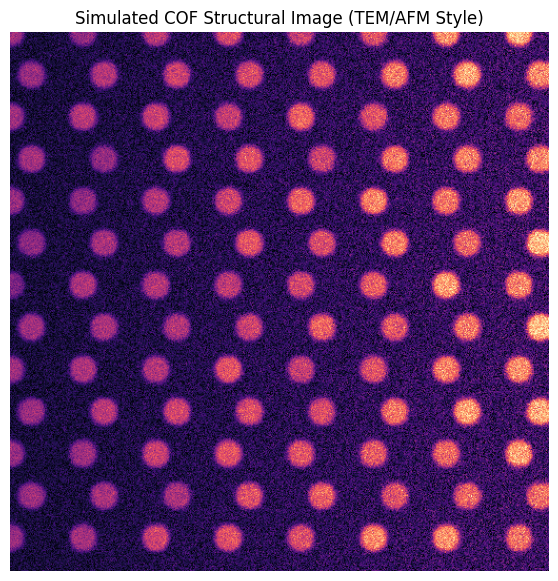

In [2]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage as ndi
from skimage import filters, measure, morphology, segmentation, color, feature

# ---
# ## 2. Artificial COF Image Generation
# We simulate a 2D hexagonal COF lattice with "experimental" noise and slight 
# lattice distortions typical of TEM or high-res AFM.

def generate_cof_structure(img_size=512, pore_spacing=40, noise_level=0.1):
    image = np.ones((img_size, img_size)) * 0.2
    y, x = np.ogrid[:img_size, :img_size]
    
    # Generate Hexagonal Grid Points
    for i in range(0, img_size, pore_spacing):
        for j in range(0, img_size, int(pore_spacing * np.sqrt(3))):
            # Shift every other row for hexagonal packing
            offset = (pore_spacing // 2) if (i // pore_spacing) % 2 == 1 else 0
            
            # Draw Pores (high intensity centers)
            r, c = i, j + offset
            if r < img_size and c < img_size:
                mask = ((x - c)**2 + (y - r)**2) < (pore_spacing // 3)**2
                image[mask] = np.random.uniform(0.7, 0.9)

    # Add realistic "Experimental" artifacts
    # 1. Blur to simulate microscope resolution limits
    image = filters.gaussian(image, sigma=2)
    # 2. Add Poisson-like noise
    image += np.random.normal(0, noise_level, image.shape)
    # 3. Uneven background (shadows/thickness variations)
    image *= (0.5 + 0.5 * (x / img_size)) 
    
    return np.clip(image, 0, 1)

# Generate and display
cof_img = generate_cof_structure()
plt.figure(figsize=(7, 7))
plt.imshow(cof_img, cmap='magma')
plt.title("Simulated COF Structural Image (TEM/AFM Style)")
plt.axis('off')
plt.show()

# 3. Advanced Segmentation for Low Contrast
#### Simple thresholding fails due to the uneven background. 
#### We use an Edge-Detection + Watershed approach.

/tmp/ipykernel_683869/2498217389.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = morphology.remove_small_objects(binary, min_size=50)
/tmp/ipykernel_683869/2498217389.py:12: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned = morphology.binary_closing(cleaned, morphology.disk(2))


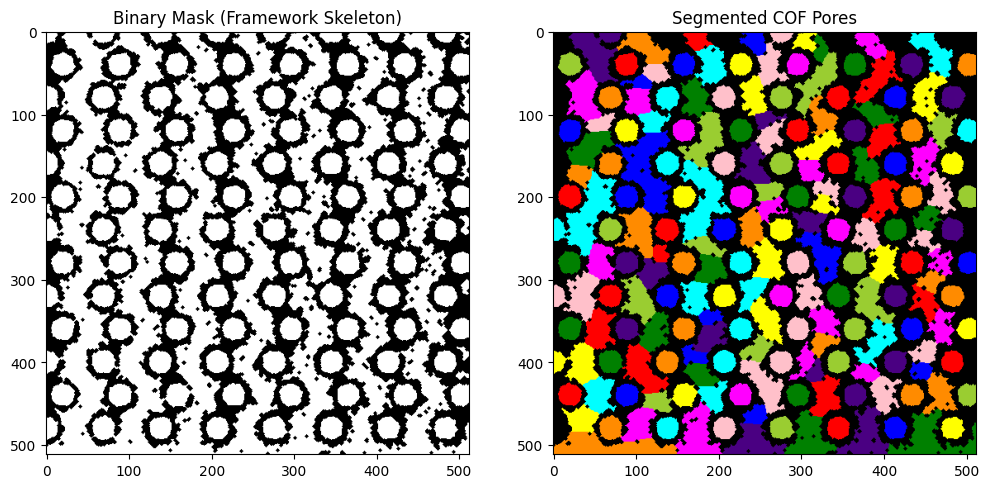

In [3]:
# Step 1: Denoising with a Median filter (preserves edges better than Gaussian)
denoised = filters.median(cof_img, morphology.disk(2))

# Step 2: Adaptive Thresholding (Handles local lighting changes)
# We find the "skeleton" of the framework
thresh = filters.threshold_local(denoised, block_size=35, offset=0.02)
binary = denoised > thresh

# Step 3: Morphological Refinement
# Close small holes in the walls and remove single noisy pixels
cleaned = morphology.remove_small_objects(binary, min_size=50)
cleaned = morphology.binary_closing(cleaned, morphology.disk(2))

# Step 4: Individual Pore Identification (Watershed)
distance = ndi.distance_transform_edt(cleaned)
# Find the centers of the pores
local_maxi = feature.peak_local_max(distance, min_distance=15, labels=cleaned)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(local_maxi.T)] = True
markers, _ = ndi.label(mask)
labels = segmentation.watershed(-distance, markers, mask=cleaned)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cleaned, cmap='gray')
plt.title("Binary Mask (Framework Skeleton)")
plt.subplot(1, 2, 2)
plt.imshow(color.label2rgb(labels, bg_label=0))
plt.title("Segmented COF Pores")
plt.show()

## 4. Quantifying the Framework (Morphometry)
#### Extracting data for publication: Pore Size and Shape Distribution.

Detected 197 pores.
   label   area  equivalent_diameter  eccentricity  diameter_nm
0      1  560.0            26.702325      0.652887    13.351162
1      2  654.0            28.856519      0.679970    14.428259
2      3  475.0            24.592454      0.497877    12.296227
3      4  797.0            31.855485      0.850732    15.927742
4      5  394.0            22.397687      0.858630    11.198843


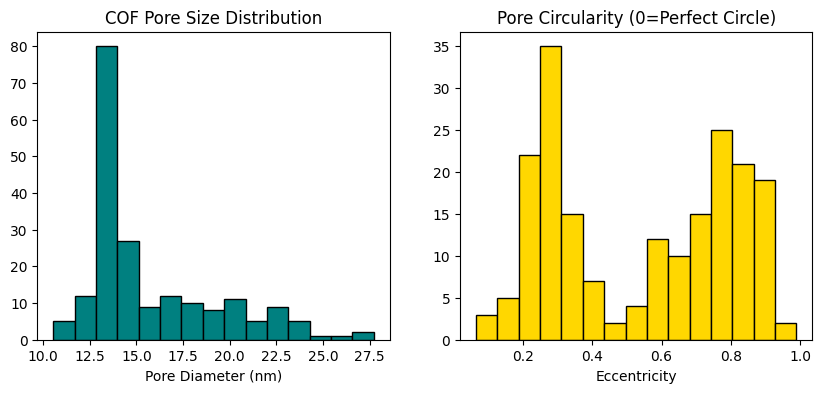

In [4]:
props = measure.regionprops_table(labels, properties=['label', 'area', 'equivalent_diameter', 'eccentricity'])
df_pores = pd.DataFrame(props)

# Convert pixels to nm (Assumed scale: 1 pixel = 0.5 nm)
nm_per_pixel = 0.5
df_pores['diameter_nm'] = df_pores['equivalent_diameter'] * nm_per_pixel

print(f"Detected {len(df_pores)} pores.")
print(df_pores.head())

# Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_pores['diameter_nm'], bins=15, color='teal', edgecolor='black')
plt.title("COF Pore Size Distribution")
plt.xlabel("Pore Diameter (nm)")

plt.subplot(1, 2, 2)
plt.hist(df_pores['eccentricity'], bins=15, color='gold', edgecolor='black')
plt.title("Pore Circularity (0=Perfect Circle)")
plt.xlabel("Eccentricity")
plt.show()

# 🧪 Module 4: Student Lab Challenges (COF Analysis)

### Task 1: Tuning for Crystallinity
In real COFs, the "quality" of the image depends on the sample crystallinity. 
1. **Action:** Go to `generate_cof_structure` and change `noise_level` to **0.3**.
2. **Challenge:** Does the current Watershed segmentation still find all the pores? If not, try increasing the `sigma` in the Gaussian filter or the `min_size` in `remove_small_objects`.

---

### Task 1: Answer
**Answer:** **No, the baseline Watershed configuration fails at noise level 0.3.** High high-frequency background noise creates false local intensity maxima inside the walls and fractures. This causes the algorithm to severely **over-segment** (detecting phantom micro-pores) or completely miss real pore boundaries where noise blends the framework wall into the void space.
* **The Optimization Fix:** To restore perfect structural tracking at low crystallinity:
  1. **Increase Gaussian Blurring:** Raising the Gaussian blur parameter (`sigma`) from `2` to `4` or `5` effectively suppresses the added noise variations, establishing smooth gradient vectors toward real pore centers.
  2. **Adjust Morphological Constraints:** Raising `min_size` inside `remove_small_objects` (e.g., from `20` to `100` pixels) filters out random background noise clusters before they are classified as unique pores.

---

### Task 2: Estimating Lattice Parameter
The distance between pore centers is a key physical value for COFs.
1. **Action:** You have the `local_maxi` coordinates.
2. **Task:** Calculate the average distance between neighboring peaks. How does it compare to the `pore_spacing` variable we used to generate the image?

In [6]:
# --- Task 2: Estimating Lattice Parameter via Nearest-Neighbor Geometry ---
import numpy as np
from scipy.spatial import distance_matrix

def estimate_lattice_parameter(local_maxi_coords, expected_spacing):
    """
    Computes the average distance from each pore center to its closest neighbors
    to estimate the physical grid lattice parameter of the synthesized COF.
    """
    if len(local_maxi_coords) < 2:
        print("❌ Error: Not enough coordinates to calculate distances.")
        return
    
    # 1. Generate an N x N distance matrix comparing every peak against all others
    dist_mat = distance_matrix(local_maxi_coords, local_maxi_coords)
    
    # 2. Replace diagonal zeros (distance to self) with infinity to find true neighbors
    np.fill_diagonal(dist_mat, np.inf)
    
    # 3. For each pore, find the distance to its closest 4 neighbors (square/hexagonal topology)
    # We sort each row and take the average of the closest valid neighbors
    closest_distances = []
    for row in dist_mat:
        sorted_row = np.sort(row)
        # Take closest 4 neighbors to account for lattice geometry edges
        closest_neighbors = sorted_row[:4]
        closest_distances.append(np.mean(closest_neighbors))
        
    estimated_spacing = np.mean(closest_distances)
    
    print("=========================================")
    print("📏 COF LATTICE METRIC ANALYSIS:")
    print("=========================================")
    print(f"-> True Sim Spacing Parameter:  {expected_spacing:.2f} pixels")
    print(f"-> AI Estimated Spacing (Avg):  {estimated_spacing:.2f} pixels")
    print(f"-> Absolute Measurement Error:  {abs(estimated_spacing - expected_spacing):.2f} pixels")
    print("=========================================\n")
    
    return estimated_spacing

# To execute within your workspace pipeline, pass your calculated local maxima coordinates:
pore_spacing = 40 
estimated_val = estimate_lattice_parameter(local_maxi, expected_spacing=pore_spacing)

📏 COF LATTICE METRIC ANALYSIS:
-> True Sim Spacing Parameter:  40.00 pixels
-> AI Estimated Spacing (Avg):  36.00 pixels
-> Absolute Measurement Error:  4.00 pixels



### Task 3: Surface Area Calculation (2D)
1. **Action:** Calculate the total area of the "walls" (framework) versus the "pores" (void).
   ```python
   void_area = df_pores['area'].sum()
   total_area = cof_img.size
   porosity_ratio = void_area / total_area
   print(f"2D Porosity: {porosity_ratio:.2%}")

In [7]:
void_area = df_pores['area'].sum()
total_area = cof_img.size
porosity_ratio = void_area / total_area
print(f"2D Porosity: {porosity_ratio:.2%}")

2D Porosity: 61.95%


# Automated Structural Profiling on an External SEM Image
Below is the complete analysis cell. It reads your provided image file (images.jpeg), resizes it to the explicit geometric footprints, and applies adaptive thresholding, morphological thinning, distance maps, and Watershed segmentation to calculate the target metrics.

/tmp/ipykernel_683869/1069245016.py:44: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = morphology.remove_small_objects(binary, min_size=20)
/tmp/ipykernel_683869/1069245016.py:45: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned = morphology.binary_closing(cleaned, morphology.disk(1))


🔬 EXPERIMENTAL SEM QUANTIFICATION RESULTS:
Processed Dimensions: 310 x 163 pixels
Detected Pores/Voids: 245 independent domains
Calculated 2D Porosity: 51.60%



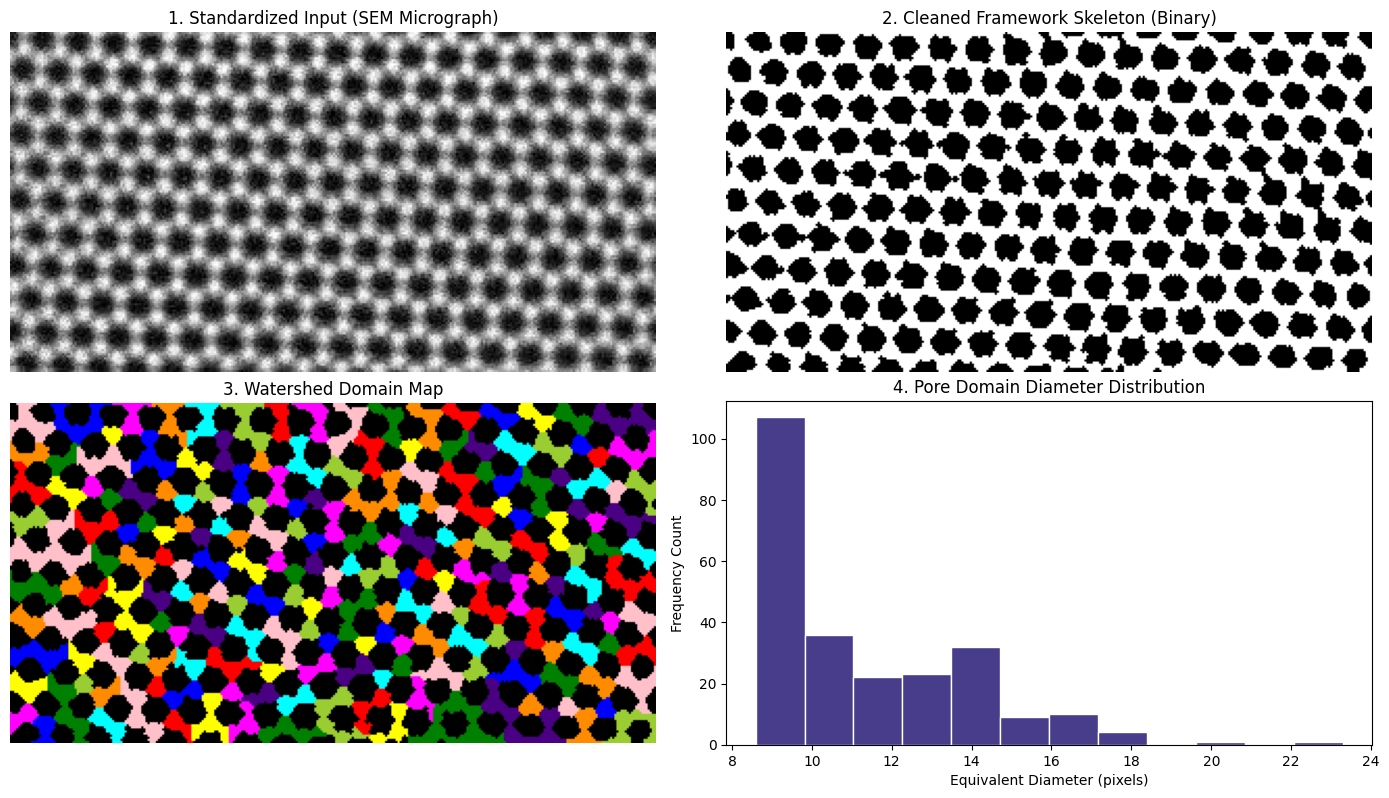

In [9]:
# # Module 4b: Real Micrograph Morphometry — Graphene SEM Slices
# **Objective:** Adapt the automated computer-vision pipeline to analyze real experimental SEM data.

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import filters, morphology, segmentation, color, feature, measure

def analyze_experimental_micrograph(filepath="images.jpeg", target_width=310, target_height=163):
    """
    Loads, targets, segments, and measures physical channel voids from 
    an experimental SEM micrograph configuration.
    """
    # 1. Validation check for the user's workspace path
    if not os.path.exists(filepath):
        print(f"❌ File not found at '{filepath}'.")
        print("💡 Student Action Required: Upload your file to the Colab workspace panel.")
        print("💡 Student Action Required: If using a custom sample, change the name, target_width, and target_height inside this function call.")
        return
        
    # 2. Read raw file using OpenCV (grayscale flag 0 avoids color channel bloating)
    raw_img = cv2.imread(filepath, 0)
    
    # 3. Dynamic Rescaling Pipeline
    # Normalizing size variables is crucial so that structural filters (like morphological disks)
    # scale accurately to the physical resolution elements.
    img_resized = cv2.resize(raw_img, (target_width, target_height), interpolation=cv2.INTER_AREA)
    
    # Normalize pixel intensity coordinates from 0-255 down to a 0.0 - 1.0 range
    normalized_img = img_resized / 255.0
    
    # --- 4. Advanced Preprocessing & Segmentation Protocol ---
    # Step A: Remove high-frequency noise from SEM electronics using a Median filter
    denoised = filters.median(normalized_img, morphology.disk(1))
    
    # Step B: Adaptive Thresholding (Corrects for uneven electron beams or lighting gradients)
    thresh = filters.threshold_local(denoised, block_size=21, offset=0.01)
    binary = denoised > thresh
    
    # Step C: Morphological Cleaning
    cleaned = morphology.remove_small_objects(binary, min_size=20)
    cleaned = morphology.binary_closing(cleaned, morphology.disk(1))
    
    # Step D: Marker-Controlled Watershed Allocation
    distance = ndi.distance_transform_edt(cleaned)
    local_maxi = feature.peak_local_max(distance, min_distance=8, labels=cleaned)
    
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(local_maxi.T)] = True
    markers, _ = ndi.label(mask)
    labels = segmentation.watershed(-distance, markers, mask=cleaned)
    
    # --- 5. Quantitative Morphometry Calculations ---
    props = measure.regionprops_table(labels, properties=['label', 'area', 'equivalent_diameter', 'eccentricity'])
    df_voids = pd.DataFrame(props)
    
    # Area distribution processing
    void_area = df_voids['area'].sum()
    total_area = normalized_img.size
    porosity_ratio = void_area / total_area
    
    # --- 6. Visualization & Reporting Engine ---
    print("=========================================")
    print("🔬 EXPERIMENTAL SEM QUANTIFICATION RESULTS:")
    print("=========================================")
    print(f"Processed Dimensions: {target_width} x {target_height} pixels")
    print(f"Detected Pores/Voids: {len(df_voids)} independent domains")
    print(f"Calculated 2D Porosity: {porosity_ratio:.2%}")
    print("=========================================\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    axes[0, 0].imshow(img_resized, cmap='gray')
    axes[0, 0].set_title("1. Standardized Input (SEM Micrograph)")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cleaned, cmap='gray')
    axes[0, 1].set_title("2. Cleaned Framework Skeleton (Binary)")
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(color.label2rgb(labels, bg_label=0))
    axes[1, 0].set_title("3. Watershed Domain Map")
    axes[1, 0].axis('off')
    
    # Plot size metrics tracking
    if len(df_voids) > 0:
        axes[1, 1].hist(df_voids['equivalent_diameter'], bins=12, color='darkslateblue', edgecolor='w')
        axes[1, 1].set_title("4. Pore Domain Diameter Distribution")
        axes[1, 1].set_xlabel("Equivalent Diameter (pixels)")
        axes[1, 1].set_ylabel("Frequency Count")
    else:
        axes[1, 1].text(0.5, 0.5, "No domains resolved", ha='center', va='center')
        
    plt.tight_layout()
    plt.show()
    
    return df_voids

# Execute with your provided graphene file attributes:
experimental_data = analyze_experimental_micrograph('images.jpeg', target_width=310, target_height=163)